# The Principled Bayesian Workflow

## Overview

A Bayesian workflow is an iterative cycle of model construction, criticism, and revision. Simply fitting a model and reporting the posterior is not the workflow — it is one step in it.

**The full workflow (Gelman et al. 2020):**

```
1. Understand the problem domain
       ↓
2. Choose a model family (likelihood + link)
       ↓
3. Specify priors
       ↓
4. Prior predictive check — do priors imply plausible data?
       ↓
5. Fit the model
       ↓
6. MCMC diagnostics — did the sampler converge?
       ↓
7. Posterior predictive check — does the model reproduce the data?
       ↓
8. Model criticism — what does the model get wrong?
       ↓
9. Model comparison / revision  ←→  back to step 2 or 3
       ↓
10. Report with uncertainty
```

This notebook walks through all 10 steps on a single ecological dataset, demonstrating how each step informs the next and how failures at each step are diagnosed and resolved.

---

## Setup

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'brms' was built under R version 4.4.3"
Loading required package: Rcpp

Loading 'brms' package (version 2.2

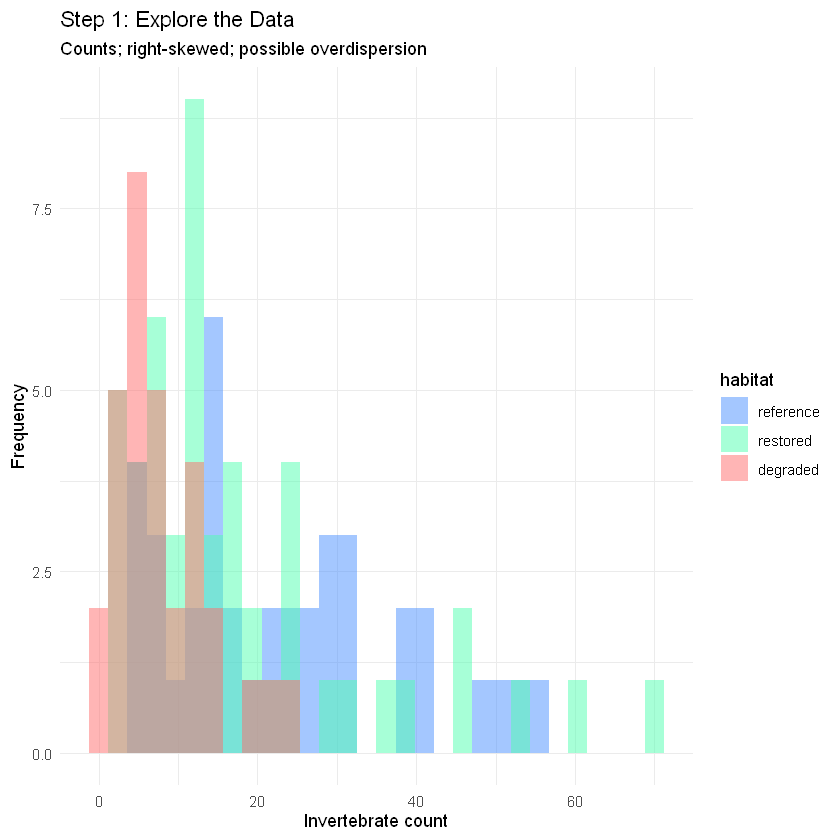

In [1]:
library(tidyverse)
library(ggplot2)
library(brms)
library(tidybayes)
library(bayesplot)
library(patchwork)

set.seed(42)

# ── Dataset: invertebrate count data (overdispersed counts) ───────────────────
# True data-generating process: negative binomial
# A naive analyst might start with Poisson — the workflow reveals the mistake
n <- 120
workflow_data <- tibble(
  site_id   = 1:n,
  nitrate   = rnorm(n, 3, 1.2),
  habitat   = factor(sample(c("reference","restored","degraded"), n,
                            replace=TRUE, prob=c(.35,.35,.30)),
                     levels=c("reference","restored","degraded")),
  log_mu    = 3.2 +
              case_when(habitat=="reference"~0, habitat=="restored"~-.3, habitat=="degraded"~-.9) +
              -.4 * scale(nitrate)[,1],
  # True process is NegBin with overdispersion
  count     = MASS::rnegbin(n, mu=exp(log_mu), theta=3)
)

ggplot(workflow_data, aes(x=count, fill=habitat)) +
  geom_histogram(bins=30, position="identity", alpha=0.5) +
  scale_fill_manual(values=c(reference="#4a8fff",restored="#4fffb0",degraded="#ff6b6b")) +
  labs(title="Step 1: Explore the Data",
       subtitle="Counts; right-skewed; possible overdispersion",
       x="Invertebrate count", y="Frequency") +
  theme_minimal()

---

## Steps 1–3: Problem Understanding, Model Family, and Priors

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Warning message:
"Removed 126 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 102 rows containing missing values or values outside the scale range
(`geom_bar()`)."


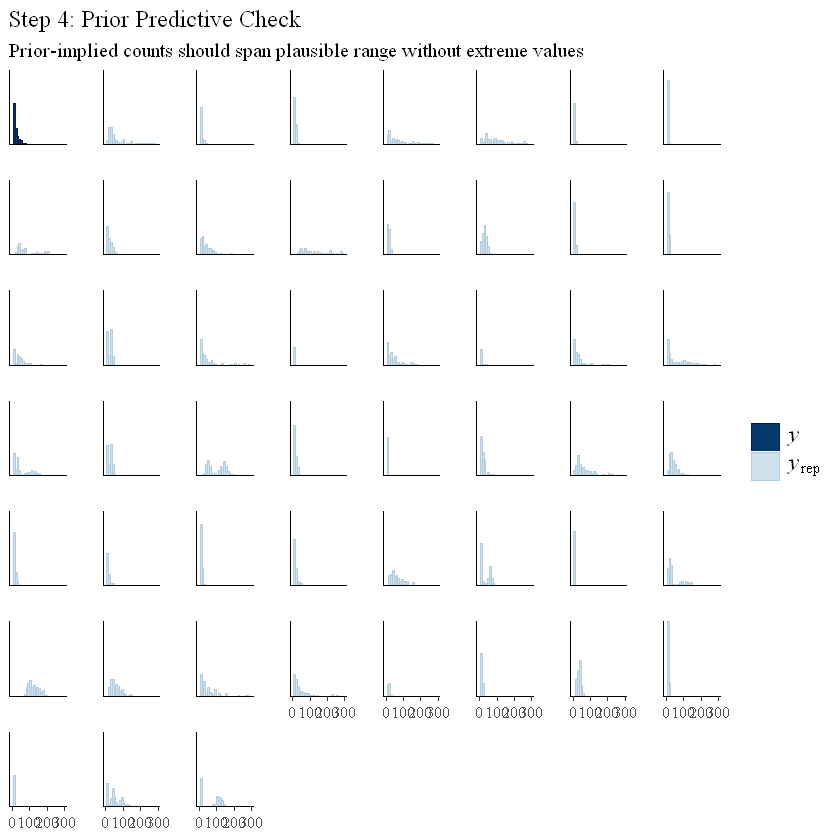

In [2]:
# Step 1: Domain understanding
# - Response is a count (non-negative integer)
# - Variance likely exceeds mean (overdispersion common in ecological counts)
# - Start with Poisson; Negative Binomial as alternative

# Step 2: Model family
# M1: Poisson (assumes mean = variance)
# M2: Negative Binomial (allows overdispersion)

# Step 3: Prior specification — think on the log scale (log link)
# exp(Intercept) = mean count at reference habitat, mean nitrate
# Reasonable count: 10–50 → log(20) ≈ 3, so Intercept ~ Normal(3, 1)
# Nitrate effect: -0.5 to +0.5 on log scale is substantial, so Normal(0, 0.5)
# Habitat effects: ~-0.5 to -1 on log scale, Normal(0, 1)

priors_pois <- c(
  prior(normal(3, 1),   class = Intercept),
  prior(normal(0, 0.5), class = b, coef = nitrate),
  prior(normal(0, 1),   class = b, coef = habitatrestored),
  prior(normal(0, 1),   class = b, coef = habitatdegraded)
)

priors_nb <- c(
  priors_pois,
  prior(gamma(2, 0.5),  class = shape)   # NegBin overdispersion; mode=2, reasonable
)

# Step 4: Prior predictive check — fit with data but sample_prior='only'
m_prior <- brm(
  count ~ nitrate + habitat,
  data         = workflow_data,
  family       = poisson(),
  prior        = priors_pois,
  sample_prior = "only",
  chains=2, iter=1000, warmup=500, cores=2, seed=42, silent=2
)

brms::pp_check(m_prior, ndraws=50, type="hist") +
  scale_x_continuous(limits=c(0, 300)) +
  labs(title="Step 4: Prior Predictive Check",
       subtitle="Prior-implied counts should span plausible range without extreme values")

---

## Step 5: Fit the Initial Model (Poisson)

In [3]:
m_poisson <- brm(
  count ~ nitrate + habitat,
  data   = workflow_data,
  family = poisson(),
  prior  = priors_pois,
  chains=4, iter=3000, warmup=1000, cores=4, seed=42, silent=2
)
print(m_poisson)

 Family: poisson 
  Links: mu = log 
Formula: count ~ nitrate + habitat 
   Data: workflow_data (Number of observations: 120) 
  Draws: 4 chains, each with iter = 3000; warmup = 1000; thin = 1;
         total post-warmup draws = 8000

Regression Coefficients:
                Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept           3.74      0.05     3.64     3.84 1.00     8781     6391
nitrate            -0.22      0.02    -0.25    -0.18 1.00     6696     5599
habitatrestored    -0.25      0.05    -0.34    -0.16 1.00     7208     6355
habitatdegraded    -0.98      0.07    -1.12    -0.84 1.00     6805     6053

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat is the potential
scale reduction factor on split chains (at convergence, Rhat = 1).


---

## Step 6: MCMC Diagnostics

Max R-hat: 1.0013  (need < 1.01)
Min ESS ratio: 0.518  (need > 0.1)
Post-warmup divergences: 0  (need 0)


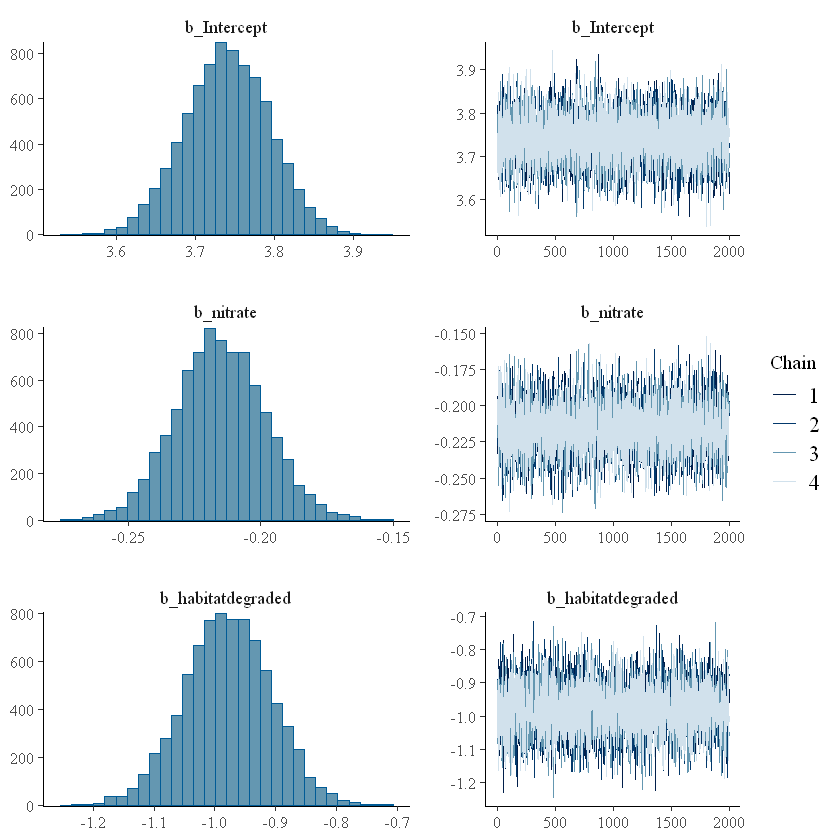

In [4]:
# Quick diagnostic check — full treatment in mcmc_diagnostics.ipynb
rhat_vals <- brms::rhat(m_poisson)
ess_ratio  <- brms::neff_ratio(m_poisson)

cat(sprintf("Max R-hat: %.4f  (need < 1.01)\n", max(rhat_vals, na.rm=TRUE)))
cat(sprintf("Min ESS ratio: %.3f  (need > 0.1)\n", min(ess_ratio, na.rm=TRUE)))
cat(sprintf("Post-warmup divergences: %d  (need 0)\n",
            sum(nuts_params(m_poisson)$Value[nuts_params(m_poisson)$Parameter=="divergent__"]==1)))

# Trace plots
plot(m_poisson, variable=c("b_Intercept","b_nitrate","b_habitatdegraded"))

---

## Step 7: Posterior Predictive Check — Discovering Model Failure

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


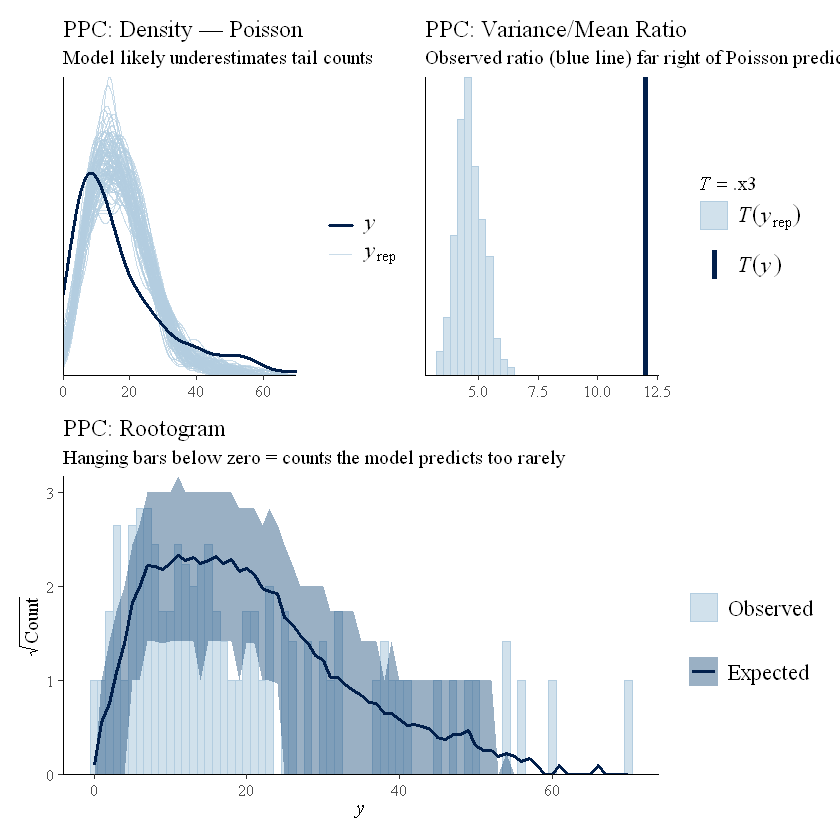

In [5]:
# PPC: the Poisson model should fail because data are overdispersed

p1 <- brms::pp_check(m_poisson, ndraws=100, type="dens_overlay") +
  labs(title="PPC: Density — Poisson",
       subtitle="Model likely underestimates tail counts")

# Test statistic: variance / mean (should be ~1 for Poisson)
var_mean_ratio <- function(y) var(y) / mean(y)

p2 <- brms::pp_check(m_poisson, ndraws=500, type="stat", stat=var_mean_ratio) +
  labs(title="PPC: Variance/Mean Ratio",
       subtitle="Observed ratio (blue line) far right of Poisson predictions → overdispersion")

p3 <- brms::pp_check(m_poisson, ndraws=100, type="rootogram") +
  labs(title="PPC: Rootogram",
       subtitle="Hanging bars below zero = counts the model predicts too rarely")

(p1 | p2) / p3

# Expected finding: observed variance/mean >> 1; Poisson model consistently
# underestimates the spread → clear signal to move to Negative Binomial

---

## Steps 8–9: Model Criticism and Revision

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


,elpd_diff,se_diff,elpd_loo,se_elpd_loo,p_loo,se_p_loo,looic,se_looic
m_negbin,0.0000,0.0000,-435.2535,10.47374,4.749915,0.7604929,870.5069,20.94749
m_poisson,-261.1667,52.8678,-696.4202,61.19727,30.609345,6.1719150,1392.8404,122.39454


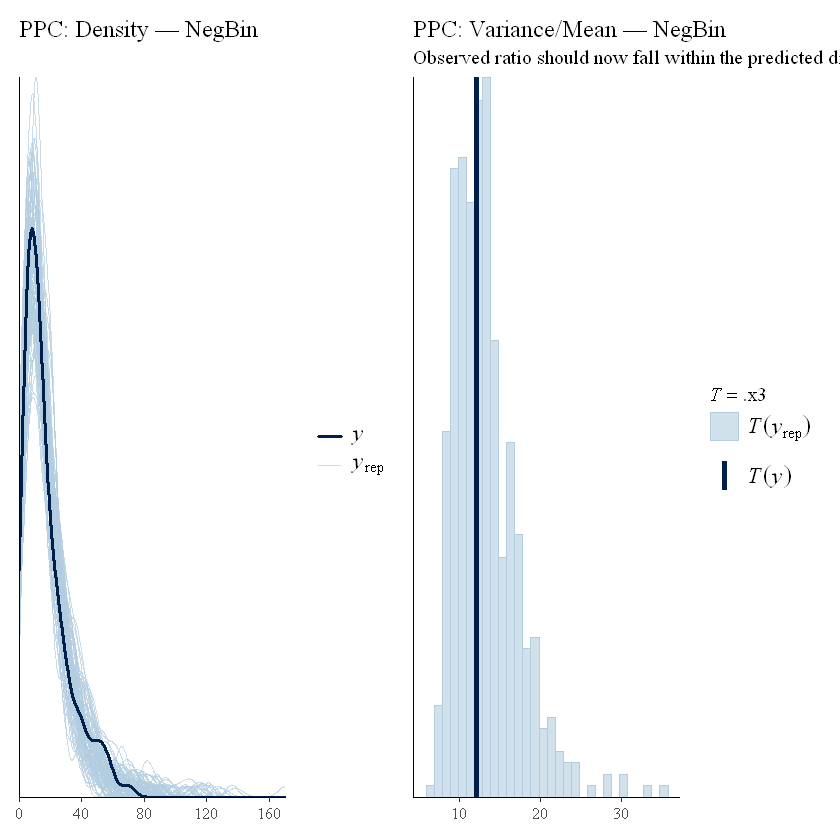

In [6]:
# Step 8: Diagnosis — Poisson PPC fails on variance/mean test → overdispersion
# Step 9: Revision — fit Negative Binomial

m_negbin <- brm(
  count ~ nitrate + habitat,
  data   = workflow_data,
  family = negbinomial(),
  prior  = priors_nb,
  chains=4, iter=3000, warmup=1000, cores=4, seed=42, silent=2
)

# ── PPC for NegBin: should pass the variance/mean test ───────────────────────
p4 <- brms::pp_check(m_negbin, ndraws=100, type="dens_overlay") +
  labs(title="PPC: Density — NegBin")
p5 <- brms::pp_check(m_negbin, ndraws=500, type="stat", stat=var_mean_ratio) +
  labs(title="PPC: Variance/Mean — NegBin",
       subtitle="Observed ratio should now fall within the predicted distribution")
(p4 | p5)

# ── Formal model comparison ───────────────────────────────────────────────────
m_poisson <- add_criterion(m_poisson, "loo")
m_negbin  <- add_criterion(m_negbin,  "loo")
loo_compare(m_poisson, m_negbin)
# NegBin should have substantially better ELPD (larger negative elpd_diff)

---

## Step 10: Report with Uncertainty

 Family: negbinomial 
  Links: mu = log 
Formula: count ~ nitrate + habitat 
   Data: workflow_data (Number of observations: 120) 
  Draws: 4 chains, each with iter = 3000; warmup = 1000; thin = 1;
         total post-warmup draws = 8000

Regression Coefficients:
                Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept           3.80      0.18     3.45     4.16 1.00     9158     6099
nitrate            -0.24      0.05    -0.34    -0.14 1.00     9341     5881
habitatrestored    -0.25      0.14    -0.51     0.02 1.00     7293     6108
habitatdegraded    -0.96      0.16    -1.27    -0.64 1.00     8076     6529

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
shape     2.76      0.41     2.03     3.65 1.00     8878     5915

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat is the potential
scale reduction factor on split chains (at

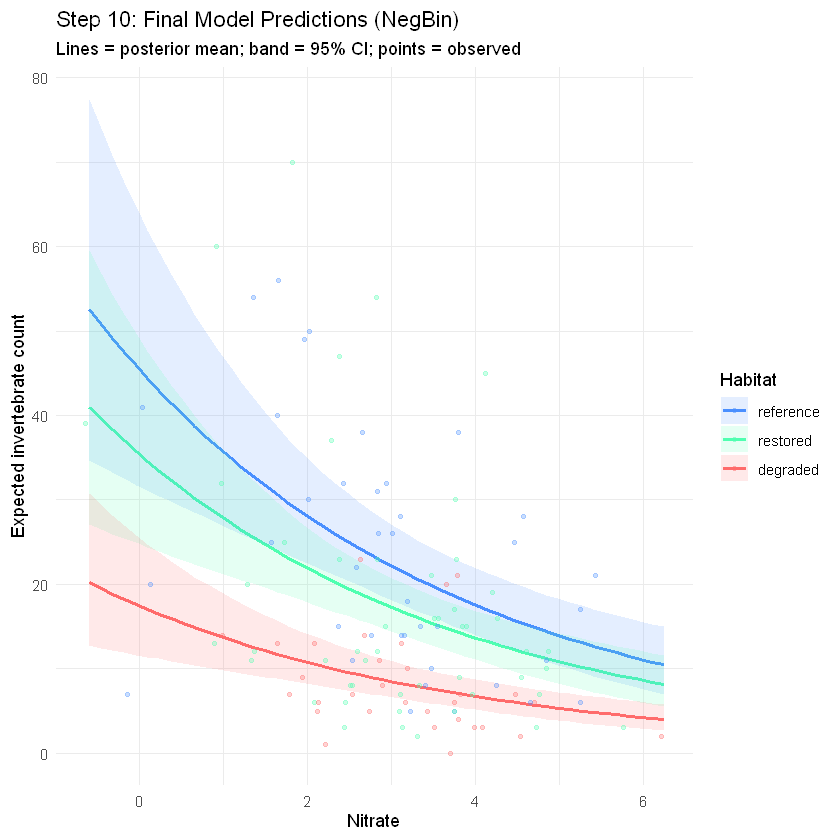

In [7]:
# Final model: NegBin
print(m_negbin)

# Posterior summaries on the rate ratio (IRR) scale: exp(coef)
irr_summary <- tidybayes::gather_draws(
  m_negbin, b_nitrate, b_habitatrestored, b_habitatdegraded
) %>%
  mutate(.value = exp(.value)) %>%   # convert log-rate to IRR
  group_by(.variable) %>%
  summarise(
    IRR       = round(mean(.value), 3),
    q2.5      = round(quantile(.value, 0.025), 3),
    q97.5     = round(quantile(.value, 0.975), 3),
    p_lt_1    = round(mean(.value < 1), 3)   # P(rate < reference | data)
  )
print(irr_summary)

# ── Prediction plot ───────────────────────────────────────────────────────────
newdata_pred <- tidyr::expand_grid(
  habitat  = levels(workflow_data$habitat),
  nitrate  = seq(min(workflow_data$nitrate), max(workflow_data$nitrate), length.out=50)
) %>%
  mutate(habitat = factor(habitat, levels=levels(workflow_data$habitat)))

pred <- tidybayes::add_epred_draws(m_negbin, newdata=newdata_pred) %>%
  group_by(habitat, nitrate) %>%
  summarise(
    mean    = mean(.epred),
    q2.5    = quantile(.epred, 0.025),
    q97.5   = quantile(.epred, 0.975),
    .groups = "drop"
  )

pal <- c(reference="#4a8fff", restored="#4fffb0", degraded="#ff6b6b")

ggplot(pred, aes(x=nitrate, y=mean, color=habitat, fill=habitat)) +
  geom_line(linewidth=1) +
  geom_ribbon(aes(ymin=q2.5, ymax=q97.5), alpha=0.15, color=NA) +
  geom_jitter(data=workflow_data, aes(y=count),
              width=0.05, height=0, alpha=0.3, size=1.2) +
  scale_color_manual(values=pal) +
  scale_fill_manual(values=pal) +
  labs(
    title    = "Step 10: Final Model Predictions (NegBin)",
    subtitle  = "Lines = posterior mean; band = 95% CI; points = observed",
    x = "Nitrate", y = "Expected invertebrate count",
    color="Habitat", fill="Habitat"
  ) +
  theme_minimal()

---

## Workflow Checklist

In [8]:
cat("
BAYESIAN WORKFLOW CHECKLIST
===========================

[ ] 1. Domain understanding
       - What is the data-generating process?
       - What are plausible parameter ranges?
       - What is the appropriate response distribution?

[ ] 2. Model family
       - Response type: Gaussian / Poisson / NegBin / Binomial / ...
       - Link function: identity / log / logit / ...
       - Hierarchical structure? (sites within catchments, etc.)

[ ] 3. Prior specification
       - Reason about priors on the parameter scale (e.g. log scale for Poisson)
       - Check get_prior() for which priors brms needs

[ ] 4. Prior predictive check
       - sample_prior='only'
       - Do simulated datasets look like plausible real data?
       - Adjust if priors imply impossible values (negatives, > 100%, etc.)

[ ] 5. Fit the model
       - chains >= 4, iter enough for ESS > 400

[ ] 6. MCMC diagnostics
       - R-hat < 1.01 for all parameters
       - Bulk and Tail ESS > 400
       - Zero post-warmup divergences
       - Trace plots: caterpillar-shaped

[ ] 7. Posterior predictive check
       - pp_check() density overlay
       - pp_check() on key test statistics (mean, SD, variance/mean, max)
       - Does the model reproduce the main features of the data?

[ ] 8. Model criticism
       - What does the model consistently get wrong?
       - Is the failure systematic (wrong family? missing predictor?)

[ ] 9. Model revision / comparison
       - Address identified failures: change family, add predictors, etc.
       - Compare with LOO-CV (see model_comparison_waic.ipynb)

[ ] 10. Report with uncertainty
        - Full posterior summaries (mean, SD, 95% CI)
        - Posterior probabilities of key hypotheses
        - Document prior choices and sensitivity (see prior_sensitivity.ipynb)
        - Prediction plots with uncertainty bands
")


BAYESIAN WORKFLOW CHECKLIST

[ ] 1. Domain understanding
       - What is the data-generating process?
       - What are plausible parameter ranges?
       - What is the appropriate response distribution?

[ ] 2. Model family
       - Response type: Gaussian / Poisson / NegBin / Binomial / ...
       - Link function: identity / log / logit / ...
       - Hierarchical structure? (sites within catchments, etc.)

[ ] 3. Prior specification
       - Reason about priors on the parameter scale (e.g. log scale for Poisson)
       - Check get_prior() for which priors brms needs

[ ] 4. Prior predictive check
       - sample_prior='only'
       - Do simulated datasets look like plausible real data?
       - Adjust if priors imply impossible values (negatives, > 100%, etc.)

[ ] 5. Fit the model
       - chains >= 4, iter enough for ESS > 400

[ ] 6. MCMC diagnostics
       - R-hat < 1.01 for all parameters
       - Bulk and Tail ESS > 400
       - Zero post-warmup divergences
       - Trace pl

---

## Common Pitfalls

**1. Stopping after getting a converged fit**  
Convergence is step 6 of 10. A perfectly converged chain from a misspecified model gives you the exactly wrong answer with great confidence. Posterior predictive checks (step 7) are non-negotiable.

**2. Using the posterior predictive check only as a density overlay**  
The density overlay is the most common PPC but is not always the most sensitive. Choose test statistics that reflect the specific failure modes of the model family — for Poisson, test variance/mean; for binary outcomes, test calibration; for time series, test autocorrelation in residuals.

**3. Treating the workflow as linear rather than iterative**  
The workflow loops. A failed PPC sends you back to model revision. A sensitivity analysis (step 9 area) may reveal the need to revisit priors. Expect to cycle through steps 2–9 multiple times on a real analysis.

**4. Selecting the model with the best LOO without prior predictive checking the alternatives**  
LOO model comparison (step 9) selects the best-predicting model from a set of candidates. It does not validate that any of the candidates is well-specified. Always PPC every candidate model before relying on LOO to distinguish them.

**5. Reporting only point estimates from the final model**  
The entire point of Bayesian inference is the posterior distribution. Report posterior means and credible intervals, show prediction uncertainty on plots, and state posterior probabilities for key hypotheses. A table of point estimates discards the most distinctive feature of the Bayesian result.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*